In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("./raw/how-financial-crisis-are-born/global_crisis_data.csv")

In [3]:
df = df.drop(columns=[
    "iso3",
    "crisis_any",
    "banking_crisis",
    "currency_crisis",
    "debt_crisis",
    "banking_crisis_next_12m",
    "currency_crisis_next_12m",
    "debt_crisis_next_12m"
])

In [4]:
df = df.dropna()

In [5]:
X = df[[
    "inflation",
    "gdp_growth",
    "unemployment",
    "fed_funds_rate",
    "real_interest_rate_10y"
]]

y = df["crisis_next_12m"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

grid = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring='recall', 
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Melhor configuração:")
print(grid.best_params_)
print("Melhor recall (CV):", grid.best_score_)

Melhor configuração:
{'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
Melhor recall (CV): 0.3879072681704261


In [9]:
best_knn = grid.best_estimator_

best_knn.fit(X_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [10]:
y_pred = best_knn.predict(X_test)

print("\n Relatório:")
print(classification_report(y_test, y_pred))


 Relatório:
              precision    recall  f1-score   support

         0.0       0.76      0.82      0.79       349
         1.0       0.51      0.43      0.46       154

    accuracy                           0.70       503
   macro avg       0.64      0.62      0.63       503
weighted avg       0.69      0.70      0.69       503



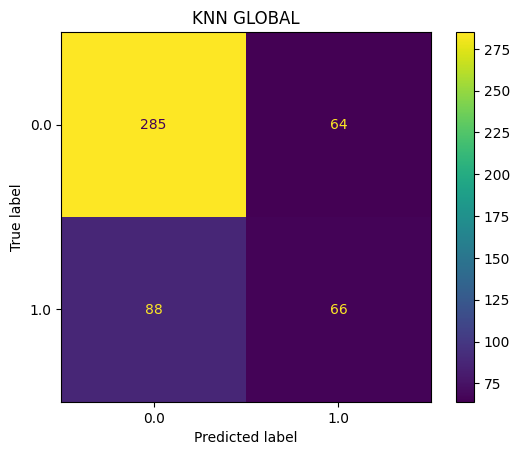

In [11]:
ConfusionMatrixDisplay.from_estimator(best_knn, X_test, y_test)
plt.title("KNN GLOBAL")
plt.show()